<a href="https://colab.research.google.com/github/Anubhavkumar076/ai_data_analysis/blob/main/Loan_Deliquent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (f1_score, accuracy_score, recall_score, precision_score, confusion_matrix)

# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv("Loan_Delinquent_Dataset.csv")
df = data.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              11548 non-null  int64 
 1   isDelinquent    11548 non-null  int64 
 2   term            11548 non-null  object
 3   gender          11548 non-null  object
 4   purpose         11548 non-null  object
 5   home_ownership  11548 non-null  object
 6   age             11548 non-null  object
 7   FICO            11548 non-null  object
dtypes: int64(2), object(6)
memory usage: 721.9+ KB


In [ ]:
df.head()

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,1,36 months,Female,House,Mortgage,>25,300-500
1,2,0,36 months,Female,House,Rent,20-25,>500
2,3,1,36 months,Female,House,Rent,>25,300-500
3,4,1,36 months,Female,Car,Mortgage,>25,300-500
4,5,1,36 months,Female,House,Rent,>25,300-500


In [ ]:
df.tail()

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
11543,11544,0,60 months,Male,other,Mortgage,>25,300-500
11544,11545,1,36 months,Male,House,Rent,20-25,300-500
11545,11546,0,36 months,Female,Personal,Mortgage,20-25,>500
11546,11547,1,36 months,Female,House,Rent,20-25,300-500
11547,11548,1,36 months,Male,Personal,Mortgage,20-25,300-500


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
display(df['term'].unique())
display(df['gender'].unique())
display(df['isDelinquent'].unique())
display(df['purpose'].unique())
display(df['home_ownership'].unique())
display(df['age'].unique())
display(df['FICO'].unique())

array(['36 months', '60 months'], dtype=object)

array(['Female', 'Male'], dtype=object)

array([1, 0])

array(['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical', 'other'],
      dtype=object)

array(['Mortgage', 'Rent', 'Own'], dtype=object)

array(['>25', '20-25'], dtype=object)

array(['300-500', '>500'], dtype=object)

In [ ]:
df['is_male'] = np.where(df['gender'] == 'male', 1, 0)
df.drop('gender', axis=1, inplace=True)
display(df.head())

,ID,isDelinquent,term,purpose,home_ownership,age,FICO,is_male
0,1,1,36 months,House,Mortgage,>25,300-500,0
1,2,0,36 months,House,Rent,20-25,>500,0
2,3,1,36 months,House,Rent,>25,300-500,0
3,4,1,36 months,Car,Mortgage,>25,300-500,0
4,5,1,36 months,House,Rent,>25,300-500,0


In [ ]:
df['is_greater_than_25'] = np.where(df['age'] == '>25', 1, 0)
df.drop("age", axis=1, inplace=True)
display(df.head())

,ID,isDelinquent,term,purpose,home_ownership,FICO,is_male,is_greater_than_25
0,1,1,36 months,House,Mortgage,300-500,0,1
1,2,0,36 months,House,Rent,>500,0,0
2,3,1,36 months,House,Rent,300-500,0,1
3,4,1,36 months,Car,Mortgage,300-500,0,1
4,5,1,36 months,House,Rent,300-500,0,1


### Sample for One-Hot Encoding

One-hot encoding creates new binary columns for each unique category. This is useful for nominal categorical data where there is no inherent order.

In [ ]:
# Create a sample DataFrame for one-hot encoding
data_onehot = pd.DataFrame({'Color': ['Red', 'Green', 'Blue', 'Red', 'Green'],
                            'Size': ['S', 'M', 'L', 'S', 'M']})

print("Original DataFrame:")
display(data_onehot)

# Apply one-hot encoding to 'Color' and 'Size' columns
data_onehot_encoded = pd.get_dummies(data_onehot, columns=['Color', 'Size'], dtype=int)

print("\nDataFrame after One-Hot Encoding:")
display(data_onehot_encoded)

Original DataFrame:


,Color,Size
0,Red,S
1,Green,M
2,Blue,L
3,Red,S
4,Green,M



DataFrame after One-Hot Encoding:


,Color_Blue,Color_Green,Color_Red,Size_L,Size_M,Size_S
0,0,0,1,0,0,1
1,0,1,0,0,1,0
2,1,0,0,1,0,0
3,0,0,1,0,0,1
4,0,1,0,0,1,0


### Sample for Label Encoding

Label encoding assigns a unique integer to each category. This is suitable for ordinal categorical data where there is a meaningful order.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a sample DataFrame for label encoding
data_label = pd.DataFrame({'Temperature': ['Cold', 'Warm', 'Hot', 'Cold', 'Hot'],
                           'Rating': ['Bad', 'Good', 'Excellent', 'Bad', 'Good']})

print("Original DataFrame:")
display(data_label)

# Initialize LabelEncoder
le = LabelEncoder()

# Apply label encoding to 'Temperature' and 'Rating' columns
data_label['Temperature_Encoded'] = le.fit_transform(data_label['Temperature'])
data_label['Rating_Encoded'] = le.fit_transform(data_label['Rating'])

print("\nDataFrame after Label Encoding:")
display(data_label)

Original DataFrame:


,Temperature,Rating
0,Cold,Bad
1,Warm,Good
2,Hot,Excellent
3,Cold,Bad
4,Hot,Good



DataFrame after Label Encoding:


,Temperature,Rating,Temperature_Encoded,Rating_Encoded
0,Cold,Bad,0,0
1,Warm,Good,2,2
2,Hot,Excellent,1,1
3,Cold,Bad,0,0
4,Hot,Good,1,2


In [ ]:
df['term'] = df['term'].str.replace(' months', '').astype(int)
display(df.head())

,ID,isDelinquent,term,purpose,home_ownership,FICO,is_male,is_greater_than_25
0,1,1,36,House,Mortgage,300-500,0,1
1,2,0,36,House,Rent,>500,0,0
2,3,1,36,House,Rent,300-500,0,1
3,4,1,36,Car,Mortgage,300-500,0,1
4,5,1,36,House,Rent,300-500,0,1


In [ ]:
display(df['term'].unique())
display(df['isDelinquent'].unique())
display(df['purpose'].unique())
display(df['home_ownership'].unique())
display(df['FICO'].unique())

array([36, 60])

array([1, 0])

array(['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical', 'other'],
      dtype=object)

array(['Mortgage', 'Rent', 'Own'], dtype=object)

array(['300-500', '>500'], dtype=object)

In [ ]:
df['is_FICO_greater_than_500'] = np.where(df['FICO'] == '>500', 1, 0)
df.drop('FICO', axis=1, inplace=True)
display(df.head())

,ID,isDelinquent,term,purpose,home_ownership,is_male,is_greater_than_25,is_FICO_greater_than_500
0,1,1,36,House,Mortgage,0,1,0
1,2,0,36,House,Rent,0,0,1
2,3,1,36,House,Rent,0,1,0
3,4,1,36,Car,Mortgage,0,1,0
4,5,1,36,House,Rent,0,1,0


In [ ]:
df['purpose'] = df['purpose'].str.replace('other', 'Other')
display(df.head())
display(df['purpose'].unique())

,ID,isDelinquent,term,purpose,home_ownership,is_male,is_greater_than_25,is_FICO_greater_than_500
0,1,1,36,House,Mortgage,0,1,0
1,2,0,36,House,Rent,0,0,1
2,3,1,36,House,Rent,0,1,0
3,4,1,36,Car,Mortgage,0,1,0
4,5,1,36,House,Rent,0,1,0


array(['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical'],
      dtype=object)

In [ ]:
encoded_data = pd.get_dummies(df, columns=['purpose', 'home_ownership'], dtype=int)
display(encoded_data.head())

,ID,isDelinquent,term,is_male,is_greater_than_25,is_FICO_greater_than_500,purpose_Car,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Mortgage,home_ownership_Own,home_ownership_Rent
0,1,1,36,0,1,0,0,1,0,0,0,0,1,0,0
1,2,0,36,0,0,1,0,1,0,0,0,0,0,0,1
2,3,1,36,0,1,0,0,1,0,0,0,0,0,0,1
3,4,1,36,0,1,0,1,0,0,0,0,0,1,0,0
4,5,1,36,0,1,0,0,1,0,0,0,0,0,0,1


In [ ]:
df.head()

,ID,isDelinquent,term,purpose,home_ownership,is_male,is_greater_than_25,is_FICO_greater_than_500
0,1,1,36,House,Mortgage,0,1,0
1,2,0,36,House,Rent,0,0,1
2,3,1,36,House,Rent,0,1,0
3,4,1,36,Car,Mortgage,0,1,0
4,5,1,36,House,Rent,0,1,0


In [ ]:
X = encoded_data.drop('isDelinquent', axis=1)
Y = encoded_data['isDelinquent']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [ ]:
display(y_train.value_counts(normalize=True))
display(y_test.value_counts(normalize=True))

,proportion
isDelinquent,
1,0.665223
0,0.334777


,proportion
isDelinquent,
1,0.676479
0,0.323521


In [ ]:
encodedModel = DecisionTreeClassifier(random_state=42)
encodedModel.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
encodedModel.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1])

In [ ]:
confusion_matrix(y_train, encodedModel.predict(X_train))

array([[2706,    0],
       [   0, 5377]])

In [ ]:
confusion_matrix(y_test, encodedModel.predict(X_test))

array([[ 644,  477],
       [ 523, 1821]])

In [ ]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['ID', 'term', 'is_male', 'is_greater_than_25', 'is_FICO_greater_than_500', 'purpose_Car', 'purpose_House', 'purpose_Medical', 'purpose_Other', 'purpose_Personal', 'purpose_Wedding', 'home_ownership_Mortgage', 'home_ownership_Own', 'home_ownership_Rent']


In [ ]:
# tree.plot_tree(encodedModel, feature_names=feature_names, filled=True)
# plt.show()

In [ ]:
# f1_score, accuracy_score, recall_score, precision_score

f1_score(y_train, encodedModel.predict(X_train))

1.0

In [ ]:
def print_scores(y_output, model_output):
  f1 = f1_score(y_output, model_output)
  accuracy = accuracy_score(y_output, model_output)
  recall = recall_score(y_output, model_output)
  precision = precision_score(y_output, model_output)

  frame = pd.DataFrame({
      "Accuracy": [accuracy],
      "Recall": [recall],
      "Precision": [precision],
      "F1 Score": [f1]
  })

  display(frame)

In [ ]:
print_scores(y_train, encodedModel.predict(X_train))

,Accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


In [ ]:
print_scores(y_test, encodedModel.predict(X_test))

,Accuracy,Recall,Precision,F1 Score
0,0.7114,0.776877,0.792428,0.784576


Clear case of overfitting

In [ ]:
max_node_depth = np.arange(2, 9, 2)
max_leaf_nodes = [50, 75, 100, 125, 150, 200]
min_samples_split_values = [10, 30, 50, 70, 90]

best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

for max_depth in max_node_depth:
  for max_leaf_node in max_leaf_nodes:
    for min_samples_split in min_samples_split_values:
      estimator = DecisionTreeClassifier(
          max_depth=max_depth, max_leaf_nodes=max_leaf_node,
          min_samples_split=min_samples_split, random_state=42)

      estimator.fit(X_train, y_train)

      y_pred = estimator.predict(X_train)

      y_test_pred = estimator.predict(X_test)

      y_pred_recall = recall_score(y_train, y_pred)
      y_test_pred_recall = recall_score(y_test, y_test_pred)

      score_diff = abs(y_pred_recall - y_test_pred_recall)

      if (score_diff < best_score_diff) & (y_test_pred_recall > best_test_score):
        best_score_diff = score_diff
        best_test_score = y_test_pred_recall
        best_estimator = estimator

prepruned_model = best_estimator




In [ ]:
prepruned_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(6), max_leaf_nodes=50,
                       min_samples_split=70, random_state=42)

In [ ]:
print_scores(y_train, prepruned_model.predict(X_train))

,Accuracy,Recall,Precision,F1 Score
0,0.792651,0.931746,0.792847,0.856703


In [ ]:
print_scores(y_test, prepruned_model.predict(X_test))

,Accuracy,Recall,Precision,F1 Score
0,0.787879,0.919795,0.797632,0.854369


Post Pruned

In [ ]:
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
clfs = []
for  ccp_alpha  in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

SyntaxError: invalid syntax (2863597874.py, line 2)

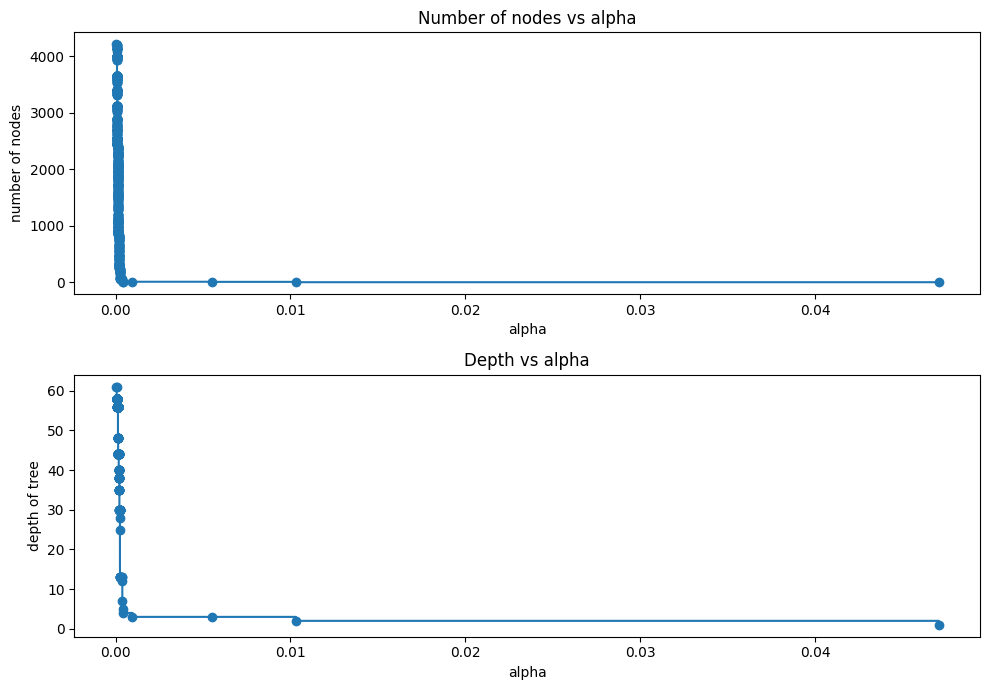

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0003981507079378277),
                       random_state=42)


In [ ]:
post_pruned_model= best_model
confusion_matrix(y_train, post_pruned_model.predict(X_train))

array([[1264, 1442],
       [ 276, 5101]])

In [ ]:
confusion_matrix(y_test, post_pruned_model.predict(X_test))

array([[ 527,  594],
       [ 127, 2217]])

In [ ]:
print_scores(y_train, post_pruned_model.predict(X_train))

,Accuracy,Recall,Precision,F1 Score
0,0.787455,0.94867,0.779612,0.855872


In [ ]:
print_scores(y_test, post_pruned_model.predict(X_test))

,Accuracy,Recall,Precision,F1 Score
0,0.791919,0.945819,0.788687,0.860136
